# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

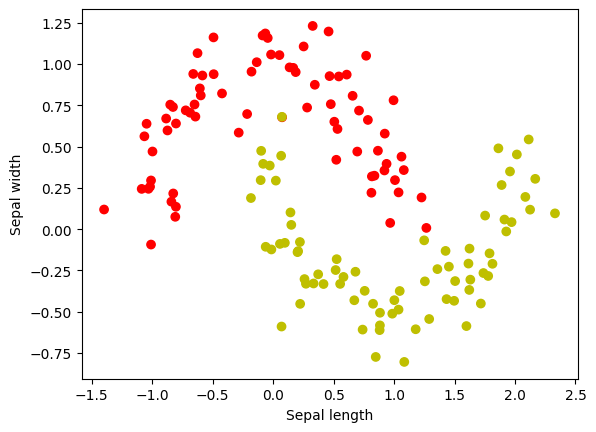

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [5]:
model.state_dict()

OrderedDict([('dense.0.weight',
              tensor([[-0.1591, -0.0658],
                      [-0.0718,  0.4017],
                      [ 0.6187, -0.5513],
                      [ 0.6313,  0.5192],
                      [ 0.1043, -0.0913]])),
             ('dense.0.bias',
              tensor([ 0.5043, -0.5927,  0.4547, -0.0752,  0.4269])),
             ('dense.2.weight',
              tensor([[ 0.0441, -0.1849, -0.1750,  0.3373,  0.0616],
                      [ 0.4122, -0.0758, -0.2876,  0.1707,  0.4061],
                      [ 0.1484,  0.1762,  0.2764, -0.3720,  0.3831],
                      [-0.0960, -0.2333,  0.1137, -0.2438,  0.0644],
                      [-0.0148, -0.4345, -0.2526, -0.1408,  0.3736]])),
             ('dense.2.bias',
              tensor([-0.3510, -0.2594, -0.2643, -0.2159,  0.2244])),
             ('dense.4.weight',
              tensor([[-0.3005,  0.1801,  0.2144,  0.3759,  0.0188],
                      [-0.1727,  0.1891,  0.3710, -0.2895, -0.3582],
     

In [6]:
class Modelo2(nn.Module):
    def __init__(self):
        super(Modelo2, self).__init__()
        self.input =  nn.Linear(2, 5)
        self.hidden = nn.Linear(5, 5)
        self.output = nn.Linear(5,3)

    def forward(self, x):
        x = self.input(x)
        x = nn.ReLU(x)
        x = self.hidden(x)
        x = nn.ReLU(x)
        x = self.output(x)

        return x

model2 = Modelo2()
print(model2)

Modelo2(
  (input): Linear(in_features=2, out_features=5, bias=True)
  (hidden): Linear(in_features=5, out_features=5, bias=True)
  (output): Linear(in_features=5, out_features=3, bias=True)
)


In [7]:
model2.state_dict()

OrderedDict([('input.weight',
              tensor([[ 0.0130,  0.4051],
                      [-0.1779,  0.3051],
                      [-0.5081,  0.4161],
                      [-0.3502, -0.4553],
                      [ 0.3497, -0.2465]])),
             ('input.bias',
              tensor([-0.6055,  0.0378,  0.2780, -0.0315, -0.3408])),
             ('hidden.weight',
              tensor([[ 0.0170,  0.0887, -0.0318, -0.1713,  0.3805],
                      [ 0.1608, -0.0708, -0.0977,  0.0924,  0.0435],
                      [ 0.3690,  0.0659, -0.3758,  0.1704,  0.3173],
                      [ 0.1806, -0.1779,  0.2010, -0.0786,  0.3704],
                      [-0.0223, -0.0866, -0.2667, -0.3616, -0.3861]])),
             ('hidden.bias',
              tensor([-0.0788, -0.4004,  0.3823, -0.0187,  0.3790])),
             ('output.weight',
              tensor([[-0.4283,  0.0308, -0.0186,  0.4276, -0.2774],
                      [ 0.0663, -0.4296,  0.4169, -0.3786, -0.4003],
            

In [8]:
class Modelo3(nn.Module):
    def __init__(self):
        super(Modelo3, self).__init__()
        self.input =  nn.Linear(2, 5)
        self.relu1 = nn.ReLU()
        self.hidden = nn.Linear(5, 5)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(5,3)

    def forward(self, x):
        x = self.input(x)
        x = self.relu1(x)
        x = self.hidden(x)
        x = self.relu2(x)
        x = self.output(x)

        return x

model3 = Modelo3()
print(model3)

Modelo3(
  (input): Linear(in_features=2, out_features=5, bias=True)
  (relu1): ReLU()
  (hidden): Linear(in_features=5, out_features=5, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=5, out_features=3, bias=True)
)


In [9]:
model3.state_dict()

OrderedDict([('input.weight',
              tensor([[-0.1883, -0.2022],
                      [-0.3555,  0.6173],
                      [ 0.6549, -0.3928],
                      [ 0.0485, -0.3128],
                      [ 0.3570, -0.1346]])),
             ('input.bias',
              tensor([-0.6996,  0.2345, -0.4054, -0.1143, -0.4958])),
             ('hidden.weight',
              tensor([[ 0.2748, -0.2528, -0.3399, -0.3170,  0.0370],
                      [ 0.3002, -0.1897, -0.0704, -0.2681,  0.0366],
                      [ 0.2607, -0.0879, -0.1985, -0.4128,  0.0799],
                      [-0.3712, -0.3241, -0.1438, -0.0529, -0.4396],
                      [ 0.0384,  0.3474, -0.0867, -0.1727,  0.0500]])),
             ('hidden.bias',
              tensor([ 0.2370,  0.3408, -0.2795, -0.3276,  0.0051])),
             ('output.weight',
              tensor([[-0.1453,  0.1710,  0.2920,  0.4096,  0.3048],
                      [-0.0175,  0.3357, -0.0063,  0.1207, -0.0969],
            

In [10]:
class Modelo_Sigmoid(nn.Module):
    def __init__(self):
        super(Modelo_Sigmoid, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 15),
            nn.Sigmoid(),
            nn.Linear(15, 25),
            nn.Sigmoid(),
            nn.Linear(25, 15),
            nn.Sigmoid(),
            nn.Linear(15,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model4 = Modelo_Sigmoid()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [11]:
class Modelo_Tanh(nn.Module):
    def __init__(self):
        super(Modelo_Tanh, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Tanh(),
            nn.Linear(5, 5),
            nn.Tanh(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model5 = Modelo_Tanh()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [12]:
class Modelo_Tanh_Simples(nn.Module):
    def __init__(self):
        super(Modelo_Tanh_Simples, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Tanh(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model6 = Modelo_Tanh_Simples()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [13]:
class Modelo_ReLU_Simples(nn.Module):
    def __init__(self):
        super(Modelo_ReLU_Simples, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 25),
            nn.ReLU(),
            nn.Linear(25,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model6 = Modelo_ReLU_Simples()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [14]:
def predict(model, inputs):
    outputs = model(inputs)
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [15]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [16]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0159)


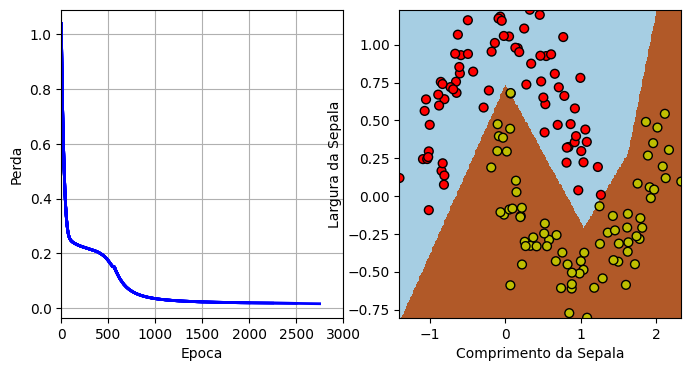

In [17]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [18]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[-0.6975,  0.2558],
        [-0.0718,  0.4017],
        [ 1.4680, -1.4013],
        [ 3.4498,  0.5563],
        [-0.5654,  0.5613]])
dense.0.bias    torch.Size([5])
tensor([ 1.4154, -0.5927,  1.9019, -0.4427,  1.7929])
dense.2.weight  torch.Size([5, 5])
tensor([[-1.3709, -0.1849, -0.6735,  2.2470, -1.5937],
        [ 0.5054, -0.0758, -0.5626,  0.6918,  0.5184],
        [ 0.2500,  0.1762,  1.9355, -1.6930,  0.6503],
        [-0.0992, -0.2333,  0.1015, -0.2439,  0.0593],
        [ 0.5178, -0.4345, -1.6124,  1.9213,  0.9388]])
dense.2.bias    torch.Size([5])
tensor([-1.5374, -0.1839,  0.1230, -0.2214,  0.9481])
dense.4.weight  torch.Size([3, 5])
tensor([[-2.6521,  0.9284, -1.0195,  0.3758,  2.1010],
        [ 2.2529, -0.3867,  2.2191, -0.2894, -1.8305],
        [ 0.0490,  0.2295, -0.9958,  0.2853, -0.6026]])
dense.4.bias    torch.Size([3])
tensor([ 0.8117,  0.0801, -1.0550])


### Avaliação do classificador

In [19]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.9933333333333333


### Matriz de confusão

In [20]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,1
1,0,74


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

## Testando os diferentes modelos de redes:

### Modelo com uma camada oculda utilizando ReLu

In [21]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [22]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.0193)


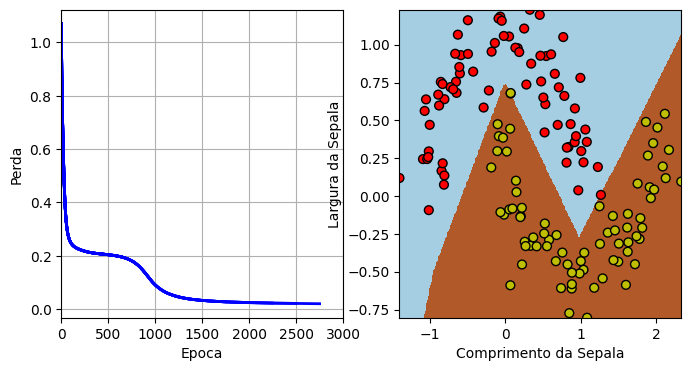

In [23]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

### Modelo Sigmoid em model4

In [24]:
class Modelo_Sigmoid(nn.Module):
    def __init__(self):
        super(Modelo_Sigmoid, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 15),
            nn.Sigmoid(),
            nn.Linear(15, 25),
            nn.Sigmoid(),
            nn.Linear(25, 15),
            nn.Sigmoid(),
            nn.Linear(15,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model4 = Modelo_Sigmoid()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [25]:
lr = 0.15

optimizer = torch.optim.SGD(model4.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.2466)


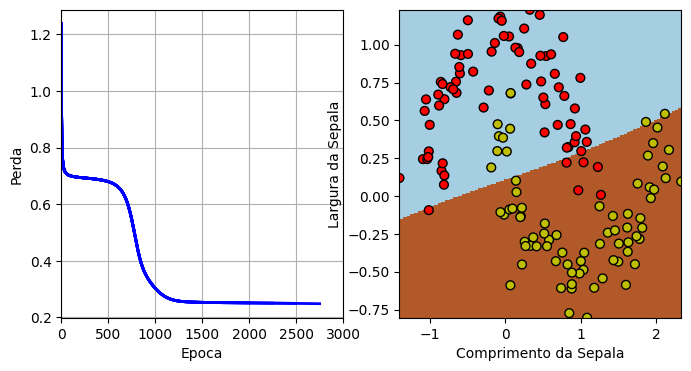

In [26]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model4, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model4(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

### Modelo Tangente Hiperbólica em model5

In [27]:
class Modelo_Tanh(nn.Module):
    def __init__(self):
        super(Modelo_Tanh, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Tanh(),
            nn.Linear(5, 5),
            nn.Tanh(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model5 = Modelo_Tanh()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [28]:
lr = 0.15

optimizer = torch.optim.SGD(model5.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.0198)


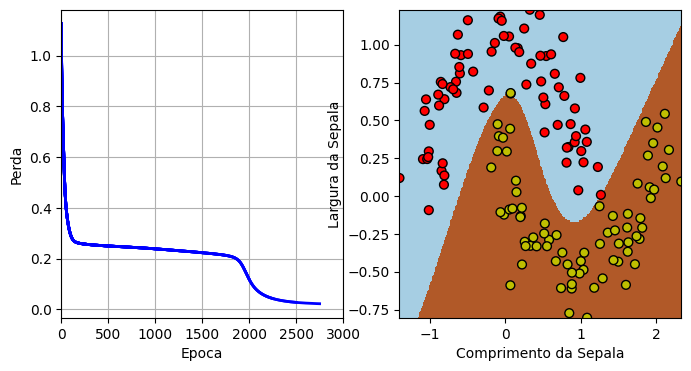

In [29]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model5, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model5(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

### Modelo utilizando Tangente Hiperbólica com somente uma camada oculta

In [30]:
class Modelo_Tanh_Simples(nn.Module):
    def __init__(self):
        super(Modelo_Tanh_Simples, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Tanh(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model6 = Modelo_Tanh_Simples()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [31]:
lr = 0.15

optimizer = torch.optim.SGD(model6.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.0363)


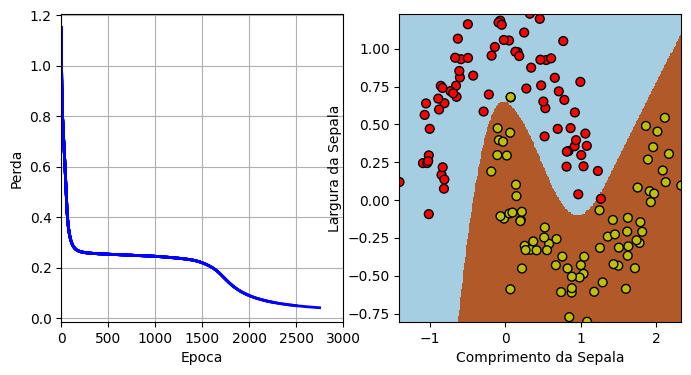

In [32]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model6, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model6(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

### Modelo Relu com somente uma camada oculta

In [33]:
class Modelo_ReLU_Simples(nn.Module):
    def __init__(self):
        super(Modelo_ReLU_Simples, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 25),
            nn.ReLU(),
            nn.Linear(25,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model7 = Modelo_ReLU_Simples()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [34]:
lr = 0.15

optimizer = torch.optim.SGD(model7.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.0271)


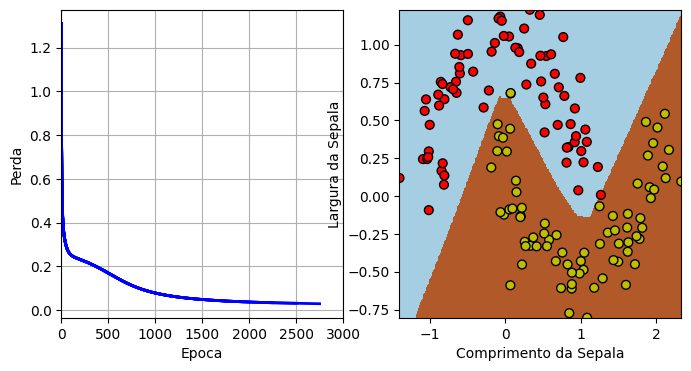

In [35]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model7, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model7(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

Foi percebido através dos experimentos uma clara tendência dos modelos obterem um melhor ajuste da curva conforme os modelos possuem maior quantidade de camadas ocultas. Outro fato percebido foi a capacidade dos modelos que utilizam tangente hiperbólica como função de ativação a possuírem curvas mais suaves em seus gráficos.

Além disso, modelos que utilizam função de ativação Sigmoid possuem dificuldade em se ajustar a curva dos dados, isso pode ser explicado pelo fato da função sigmoide retornar valores entre 0 e 1, o que pode não ser desejável em alguns casos de treinamento de modelos, fato que não ocorre com outras funções de ativação como ReLu e TanH

## Criando um modelo com diversas camadas ocultas que utilizam sigmoide

In [36]:
class Modelo_Multiplas_Sigmoides(nn.Module):
    def __init__(self):
        super(Modelo_Multiplas_Sigmoides, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 5),
            nn.Sigmoid(),
            nn.Linear(5, 5),
            nn.Sigmoid(),
            nn.Linear(5, 5),
            nn.Sigmoid(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model8 = Modelo_Multiplas_Sigmoides()
print(model8)

Modelo_Multiplas_Sigmoides(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=5, out_features=5, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=5, out_features=5, bias=True)
    (7): Sigmoid()
    (8): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [37]:
lr = 0.15

optimizer = torch.optim.SGD(model8.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.6926)


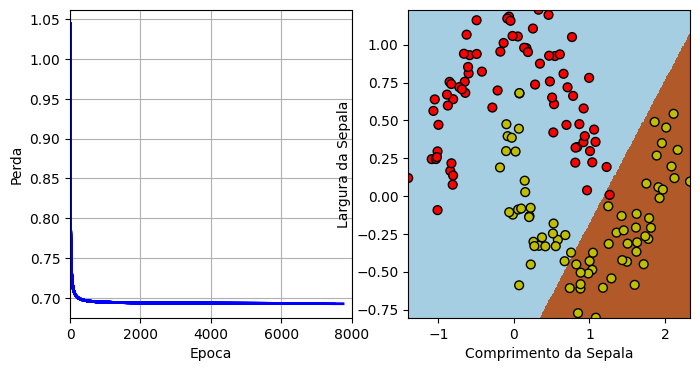

In [38]:
batch_size = 150
nb_epoch = 8000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model8, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model8(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

Observa-se que mesmo que seja utilizado muitas camadas ocultas no modelo, ele tem dificulade em se ajustar aos dados da distribuição. Isso ocorre em parte por características da função sigmoide, sendo esta utilizada, geralmente, nas ultimas camadas do modelo para gerar as classificações finais

### Não utilização de ativação não linear entre camadas

Quando não se utiliza funções de ativação não lineares entre as camadas, o modelo não é capaz de representar distribuições não lineares nos dados, de forma que o modelo somente conseguirá representar funções lineares durante todo o treinamento.

In [39]:
class Modelo_Linear(nn.Module):
    def __init__(self):
        super(Modelo_Linear, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.Linear(5, 5),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model9 = Modelo_Linear()
print(model9)

Modelo_Linear(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=5, bias=True)
    (2): Linear(in_features=5, out_features=3, bias=True)
  )
)


In [40]:
lr = 0.15

optimizer = torch.optim.SGD(model9.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.2500)


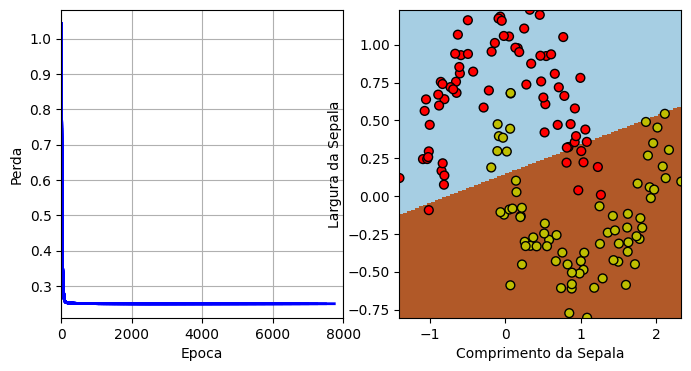

In [41]:
batch_size = 150
nb_epoch = 8000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model9, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model9(X_tensor)

    loss = criterion(output, Y_tensor)

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)